# Introduction

My goal with this post is to review and explore hypothesis testing with data. I chose Kaggle's Concrete Comprehensive Strength dataset because I am interested in material science and wanted a dataset suitable for a variety of hypothesis tests. I start out by reviewing hypothesis testing and then exploring different statistics with this dataset. 

**Hypothesis Testing**

Hypothesis testing is a method for determining whether or not data supports a particular hypothesis. The basic steps are as follows:

1. State the null hypothesis (H0) and the alternate hypothesis (H1) where
   - H0 is a statement about the value of a parameter of our data 
   - H1 is a statement we accept about our data if there is sufficient evidence to indicate that H0 is false.

*for the concrete dataset...*

2. Select a level of significance.

The level of significance is the probability of rejecting the null hypothesis when it is actually true. 

3. Identify the test statistic.

The choice of test statistic depends on the data. There are different test statistics that are appropriate for when sample sizes are large or small, or for when we are ...

4. State the decision rule.

5. Make a decision.


**One-sample t-test**

**Two-sample t-test**

**F-test**

**One-way ANOVA**

**Chi-squared**


In [298]:
# import libraries
import numpy as np
import pandas as pd
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro
from scipy.stats import ttest_ind
import scipy.stats as stats

sns.set_theme(style = 'ticks')

In [160]:
concrete = pd.read_csv("data/concrete_data.csv")

In [162]:
concrete.head()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [166]:
concrete.sort_index()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


# About the data

[Concrete Compressive Strength Data](https://www.kaggle.com/datasets/elikplim/concrete-compressive-strength-data-set/data)

**Features**

- concrete_compressive_strength (MPa): measure of a material's ability to withstand compressive loads without failing.
- age (days)

- blast_furnace_slag: amount of blast furnace slag in concrete mixture (kg per cubic meter)
- fly_ash: amount of fly ash in concrete mixture (kg per cubic meter)
- water: amount of water in concrete mixture (kg per cubic meter)
- superplasticizer: amount of superplasticizer in concrete mixture (kg per cubic meter)

    Helps increase flowability.
  
- coarse_aggregate: amount of coarse_aggregate in concrete mixture (kg per cubic meter)
- fine_aggregate : amount of fine_aggregate in concrete mixture (kg per cubic meter)

In [171]:
concrete.shape

(1030, 9)

In [173]:
concrete.describe()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [175]:
concrete.isna().sum()

cement                           0
blast_furnace_slag               0
fly_ash                          0
water                            0
superplasticizer                 0
coarse_aggregate                 0
fine_aggregate                   0
age                              0
concrete_compressive_strength    0
dtype: int64

In [177]:
concrete.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cement                         1030 non-null   float64
 1   blast_furnace_slag             1030 non-null   float64
 2   fly_ash                        1030 non-null   float64
 3   water                          1030 non-null   float64
 4   superplasticizer               1030 non-null   float64
 5   coarse_aggregate               1030 non-null   float64
 6   fine_aggregate                 1030 non-null   float64
 7   age                            1030 non-null   int64  
 8   concrete_compressive_strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


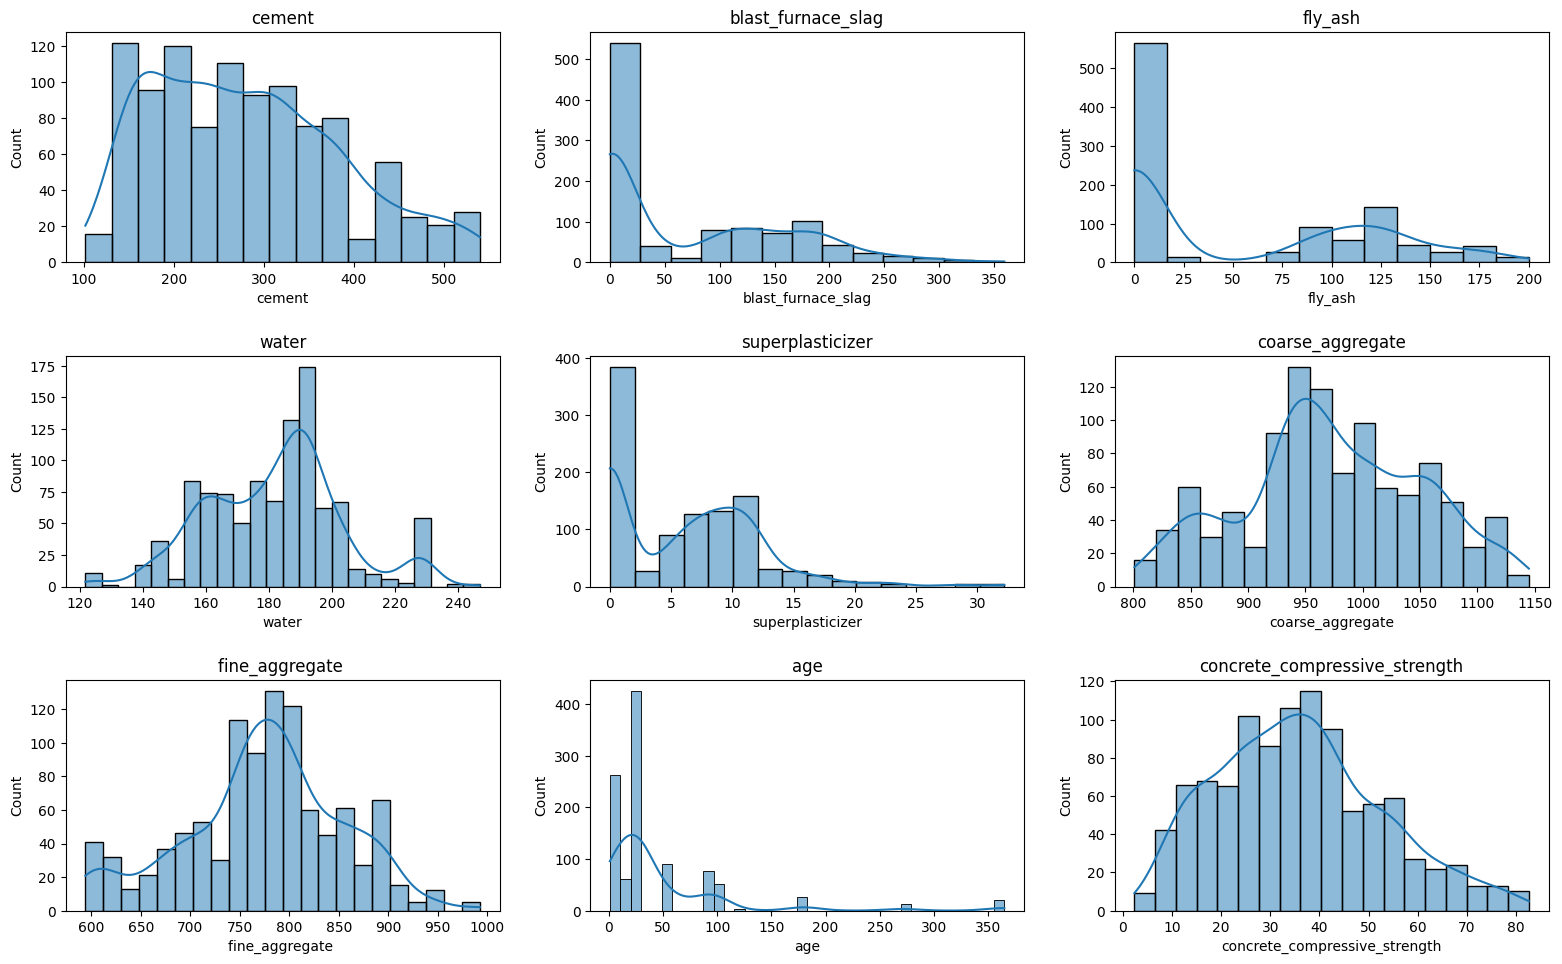

In [181]:
# visualize the data
fig, axes = plt.subplots(ncols=3, nrows=3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(concrete.columns):
    sns.histplot(x=concrete[feature], kde=True, ax=axes[i])
    axes[i].set_title(f'{feature}')

plt.tight_layout(pad=2.0) 
plt.show()

In [188]:
concrete['age'].value_counts(ascending=False)

age
28     425
3      134
7      126
56      91
14      62
90      54
100     52
180     26
91      22
365     14
270     13
360      6
120      3
1        2
Name: count, dtype: int64

In [190]:
concrete['age'].value_counts().index.to_list()

[28, 3, 7, 56, 14, 90, 100, 180, 91, 365, 270, 360, 120, 1]

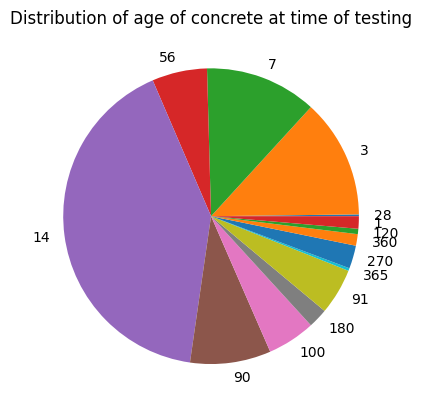

In [192]:
plt.pie(concrete['age'].value_counts().sort_index(), 
        labels=concrete['age'].value_counts().index.to_list())
plt.title('Distribution of age of concrete at time of testing')
plt.show()

In [209]:
corr = concrete.corr()

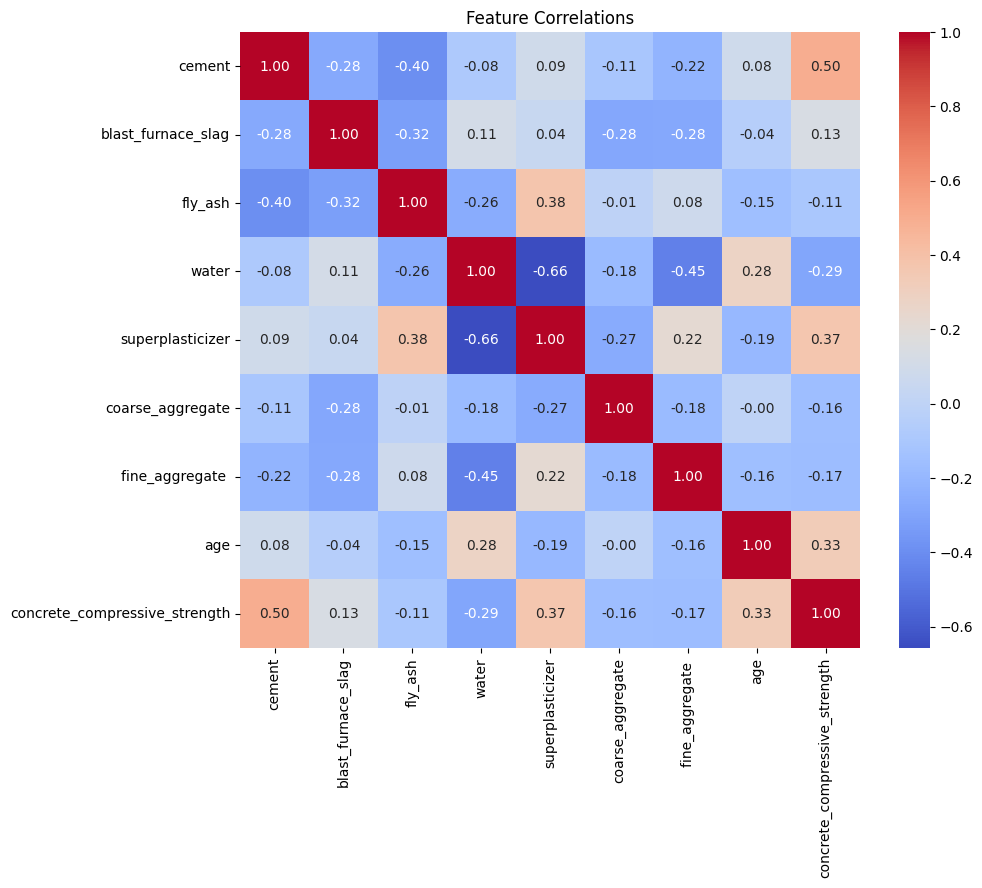

In [211]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlations')
plt.show()

Cement, superplasticizer, age, and water have the highest correlations with strength. Look at these more closely.

Also note that water and superplasticizer are somewhat correlated. Superplasticizer is added to concrete mixes to reduce the amount of water needed. So as superplasticizer goes up, water will go down.

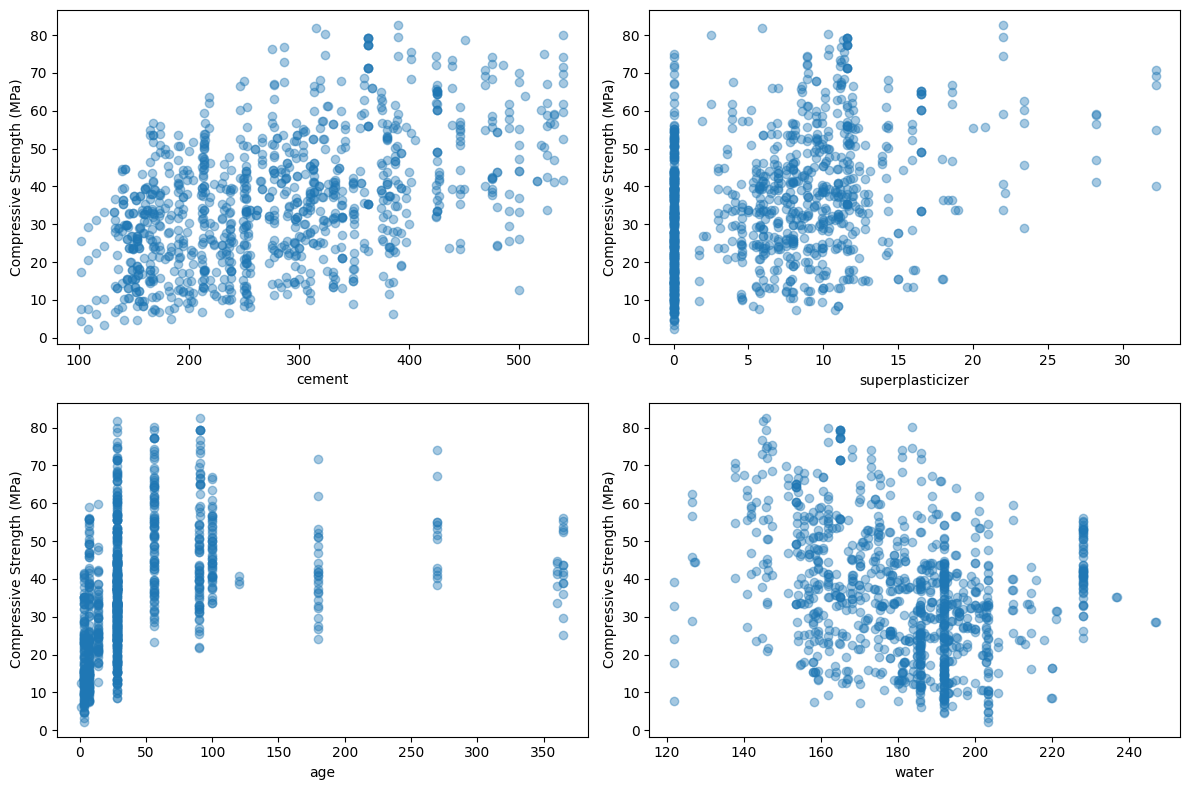

In [215]:
features = ['cement', 'superplasticizer', 'age', 'water']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feat in zip(axes.flatten(), features):
    ax.scatter(concrete[feat], concrete['concrete_compressive_strength'], alpha=0.4)
    ax.set_xlabel(feat)
    ax.set_ylabel('Compressive Strength (MPa)')

plt.tight_layout()
plt.show()

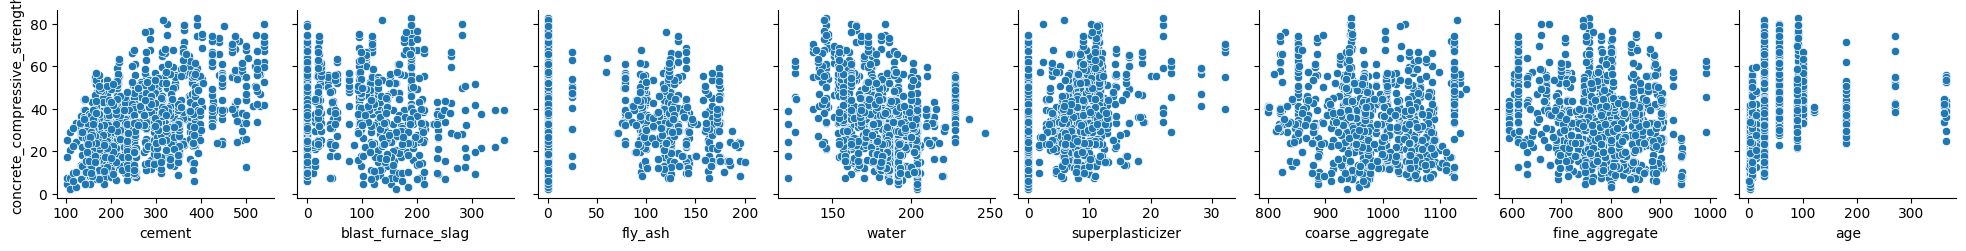

In [219]:
# look at how strength interacts with each feature (this is just a single row of the larger pairplot grid)
sns.pairplot(concrete, y_vars=['concrete_compressive_strength'], x_vars=concrete.columns[:-1])
plt.show()

Some questions to address with hypothesis testing

- Do mixes with fly ash have higher compressive strength than those without?
- Do mixes with superplasticizer outperform those without?
- Does high cement content (above vs. below median) produce significantly stronger concrete?

In [226]:
(concrete == 0).sum()

cement                             0
blast_furnace_slag               471
fly_ash                          566
water                              0
superplasticizer                 379
coarse_aggregate                   0
fine_aggregate                     0
age                                0
concrete_compressive_strength      0
dtype: int64

Every material instance is composed of a mixture of cement, water, coarse_aggregate, and fine_aggregate. Some materials also have additional blast_furnace_slag, fly_ash, and superplasticizer in their makeup. Can create features indicating whether a material does or does not have one of these additives to compare. 

In [228]:
# add binary indicators for additives
concrete['has_slag'] = (concrete['blast_furnace_slag'] > 0).astype(int)
concrete['has_ash'] = (concrete['fly_ash'] > 0).astype(int)
concrete['has_sp'] = (concrete['superplasticizer'] > 0).astype(int)

In [230]:
concrete.head(2)

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength,has_slag,has_ash,has_sp
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,0,0,1
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,0,0,1


# Question 1:

Does mean compressive strength differ significantly based on whether the material has a given additive (slag, ash, or superplasticizer)? 

H0: the mean compressive strength does not differ significantly
H1: the mean compressive strength does differ significantly 

There are 3 assumptions to consider:
1. Observations are independent. This is a study design issue? I assume that the observations do not depend on one another.
2. Compressive strength data within each group is normally distributed.

In [236]:
concrete[concrete['has_slag'] == 1]

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength,has_slag,has_ash,has_sp
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,1,0,0
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,1,0,0
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,1,0,0
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.03,1,0,0
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,365,43.70,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1024,166.0,259.7,0.0,183.2,12.7,858.8,826.8,28,37.92,1,0,1
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28,1,1,1
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70,1,1,1
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77,1,0,1


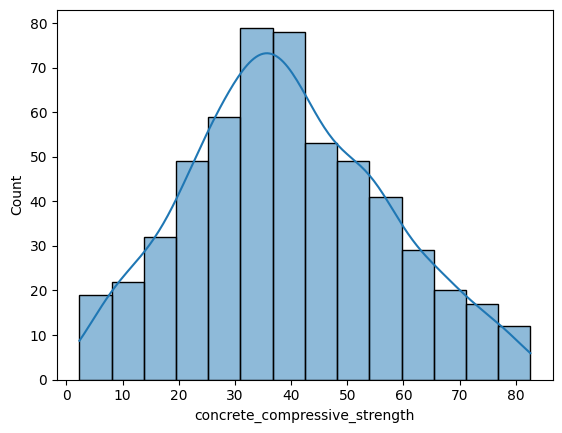

In [258]:
sns.histplot(concrete[concrete['has_slag'] == 1]['concrete_compressive_strength'], kde=True);

In [270]:
no_slag = concrete[concrete['has_slag'] == 0]['concrete_compressive_strength']
has_slag = concrete[concrete['has_slag'] == 1]['concrete_compressive_strength']

### Shapiro-Wilk test

Test for normality. H0 is that the population is normally distributed.
For p-value > 0.05, accept the null hypothesis.

In [274]:
# Shapiro-Wilk test 
print(shapiro(no_slag))
print(shapiro(has_slag))

ShapiroResult(statistic=0.9673880026503141, pvalue=9.930181741608333e-09)
ShapiroResult(statistic=0.9881070092441648, pvalue=0.0001637022878122511)


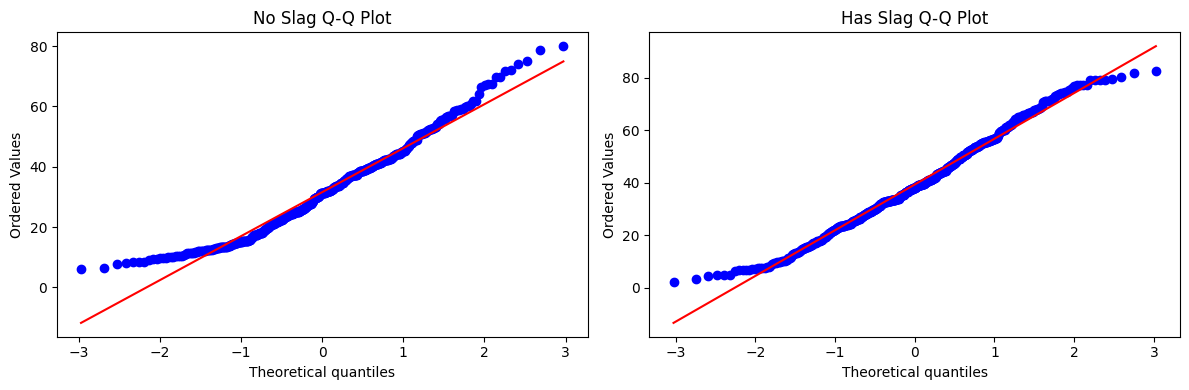

In [294]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(no_slag, plot=axes[0])
axes[0].set_title('No Slag Q-Q Plot')
stats.probplot(has_slag, plot=axes[1])
axes[1].set_title('Has Slag Q-Q Plot')
plt.tight_layout();

3. Equality of variances

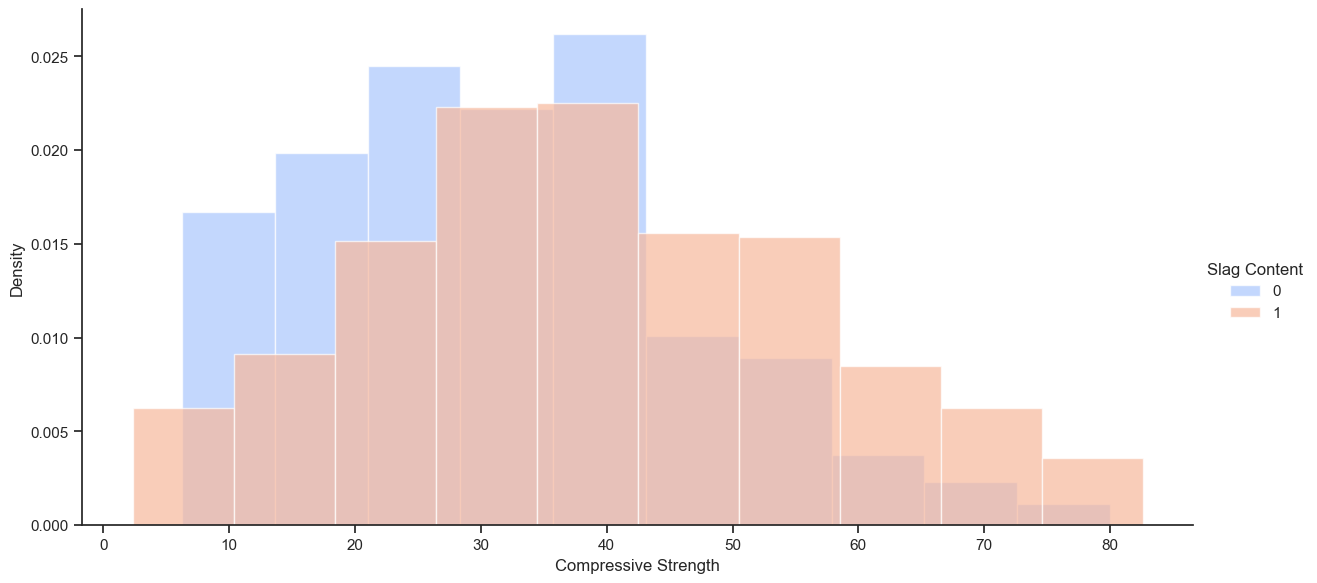

In [300]:
ax = sns.FacetGrid(concrete, hue='has_slag', palette='coolwarm',height = 6, aspect = 2)
ax.map(plt.hist,'concrete_compressive_strength', bins=10, alpha=0.7, density = True)
ax.set(xlabel = 'Compressive Strength', ylabel = 'Density')
ax.add_legend(title = 'Slag Content');

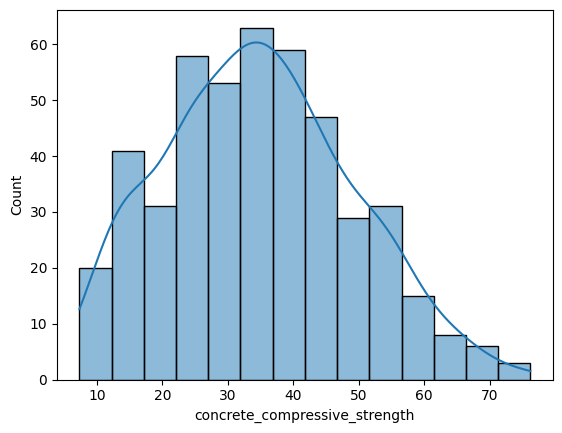

In [260]:
sns.histplot(concrete[concrete['has_ash'] == 1]['concrete_compressive_strength'], kde=True);

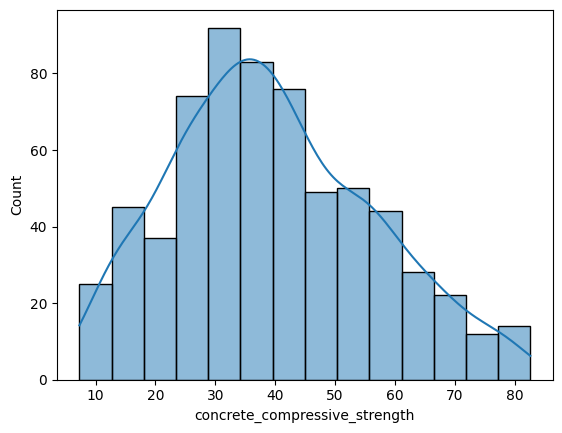

In [262]:
sns.histplot(concrete[concrete['has_sp'] == 1]['concrete_compressive_strength'], kde=True);

# Feature engineering

- water-to-cement ratio

      w/c = water / cement

Typical values generally fall within the interval of 0.40 and 0.60 (wikipedia). This ratio is perhaps the most important factor for determining the quality and properties of hardened concrete. A lower ratio contributes to strength and durability, but affects workability at time of forming. 


- total binder content

      tb = cement + ash + slag

- aggregate-to-cement ratio

      a/c = (coarse_aggregate + fine_aggregate) / cement

Typically, volume of a mix is 60-70% aggregate

  

- age strength proxy

      asp = sqrt(age)

Models non-linear strength over time. Concrete develops strength rapidly early on before slowing down.

Assumption: the industry benchmark for general purpose compressive strength is 35 MPa